# CIFAR-10 EDA — Generative Adversarial Networks (GANs)

**Dataset:** CIFAR-10 (Krizhevsky, 2009)  
**Source:** 60,000 color images (32×32×3), 10 object classes  
**Samples:** 60,000 (50K train / 10K test) | **Features:** 3,072 (flattened) | **Target:** 10 classes (labels for conditional GAN only)  
**Task:** Learn to generate new images from random noise — first generative model in the project

## Purpose
Inspect raw data before preprocessing:
- Understand the target distribution the generator must learn to produce
- Verify pixel distributions and data types across RGB channels
- Confirm class balance (important for conditional GAN training signal)
- Analyze intra-class diversity (previews what mode collapse looks like)
- Establish per-channel statistics the generator must match
- Every finding maps to a specific preprocessing or architecture decision

In [1]:
# Step 1: Setup

"""
Load CIFAR-10 raw data via Keras and inspect basic properties.
Same dataset as Autoencoders (#10), but GANs will generate new images
from random noise rather than reconstruct existing ones.
"""

import numpy as np
import matplotlib.pyplot as plt
import os

# Configuration
RANDOM_STATE = 113
np.random.seed(RANDOM_STATE)
EDA_DIR = '../data/raw/eda_gans'
os.makedirs(EDA_DIR, exist_ok=True)

# CIFAR-10 class names (index matches label 0-9)
CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Download CIFAR-10 via Keras (cached after first download)
from tensorflow.keras.datasets import cifar10
(X_train_raw, y_train), (X_test_raw, y_test) = cifar10.load_data()

# Keras returns labels as (N, 1) — flatten to (N,)
y_train = y_train.flatten()
y_test = y_test.flatten()

print("=" * 60)
print("CIFAR-10 — Raw Data Summary")
print("=" * 60)
print(f"Train: {X_train_raw.shape} | Test: {X_test_raw.shape}")
print(f"Labels — Train: {y_train.shape} | Test: {y_test.shape}")
print(f"Total samples: {len(X_train_raw) + len(X_test_raw):,}")
print(f"Image shape: {X_train_raw.shape[1:]} (H x W x C)")
print(f"Features (flattened): {np.prod(X_train_raw.shape[1:]):,}")
print(f"Dtype: {X_train_raw.dtype}")
print(f"Pixel range: [{X_train_raw.min()}, {X_train_raw.max()}]")
print(f"Classes ({len(CLASS_NAMES)}): {', '.join(CLASS_NAMES)}")
print(f"Label range: [{y_train.min()}, {y_train.max()}] (0-indexed)")

CIFAR-10 — Raw Data Summary
Train: (50000, 32, 32, 3) | Test: (10000, 32, 32, 3)
Labels — Train: (50000,) | Test: (10000,)
Total samples: 60,000
Image shape: (32, 32, 3) (H x W x C)
Features (flattened): 3,072
Dtype: uint8
Pixel range: [0, 255]
Classes (10): airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck
Label range: [0, 9] (0-indexed)


[1/5] CLASS DISTRIBUTION

Class distribution:
Class             Train    Test   Total
----------------------------------------
airplane          5,000   1,000   6,000
automobile        5,000   1,000   6,000
bird              5,000   1,000   6,000
cat               5,000   1,000   6,000
deer              5,000   1,000   6,000
dog               5,000   1,000   6,000
frog              5,000   1,000   6,000
horse             5,000   1,000   6,000
ship              5,000   1,000   6,000
truck             5,000   1,000   6,000
----------------------------------------
TOTAL            50,000  10,000  60,000

Train imbalance ratio: 1.0x (1.0 = perfectly balanced)


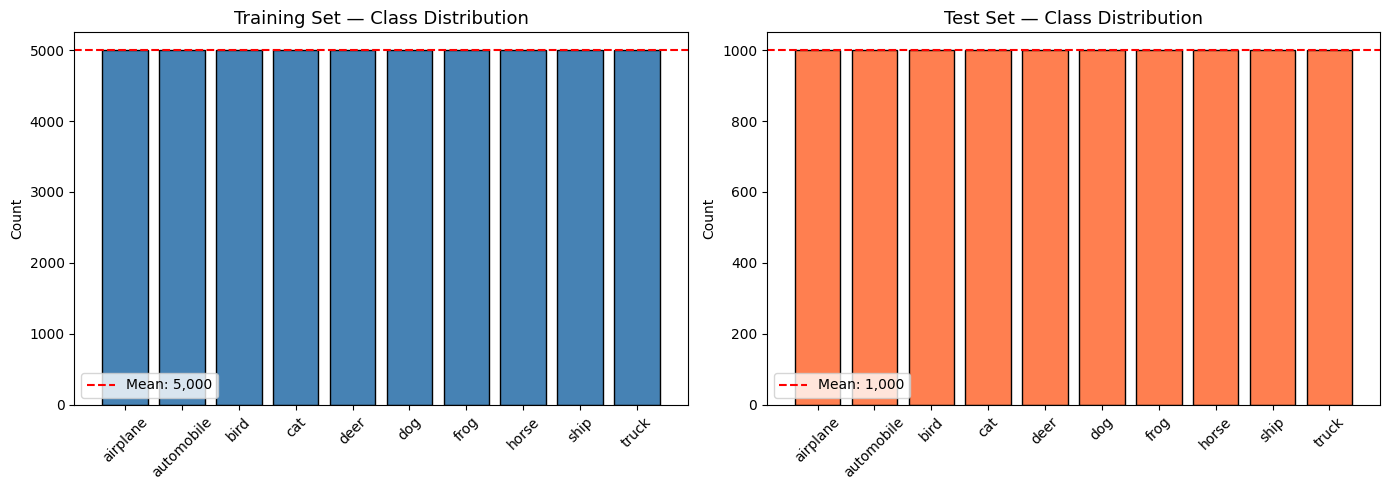


Key takeaway: Perfectly balanced — cGAN will get equal training signal per class.


In [2]:
# Step 2: [1/5] Class Distribution

"""
Verify class balance across train and test sets.
For GANs: balanced classes mean the generator sees equal examples of each
category during training. For conditional GAN (cGAN), this ensures
equal training signal per class — no class gets under-represented.
"""

print("=" * 60)
print("[1/5] CLASS DISTRIBUTION")
print("=" * 60)

# Count samples per class
train_counts = np.bincount(y_train)
test_counts = np.bincount(y_test)

print("\nClass distribution:")
print(f"{'Class':<15} {'Train':>7} {'Test':>7} {'Total':>7}")
print("-" * 40)
for i, name in enumerate(CLASS_NAMES):
    print(f"{name:<15} {train_counts[i]:>7,} {test_counts[i]:>7,} {train_counts[i] + test_counts[i]:>7,}")
print("-" * 40)
print(f"{'TOTAL':<15} {train_counts.sum():>7,} {test_counts.sum():>7,} {train_counts.sum() + test_counts.sum():>7,}")

# Imbalance ratio
train_ratio = train_counts.max() / train_counts.min()
print(f"\nTrain imbalance ratio: {train_ratio:.1f}x (1.0 = perfectly balanced)")

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(CLASS_NAMES, train_counts, color='steelblue', edgecolor='black')
axes[0].set_title('Training Set — Class Distribution', fontsize=13)
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
axes[0].axhline(y=train_counts.mean(), color='red', linestyle='--', label=f'Mean: {train_counts.mean():,.0f}')
axes[0].legend()

axes[1].bar(CLASS_NAMES, test_counts, color='coral', edgecolor='black')
axes[1].set_title('Test Set — Class Distribution', fontsize=13)
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)
axes[1].axhline(y=test_counts.mean(), color='red', linestyle='--', label=f'Mean: {test_counts.mean():,.0f}')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, 'class_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\nKey takeaway: Perfectly balanced — cGAN will get equal training signal per class.")

[2/5] PER-CLASS VISUAL SURVEY


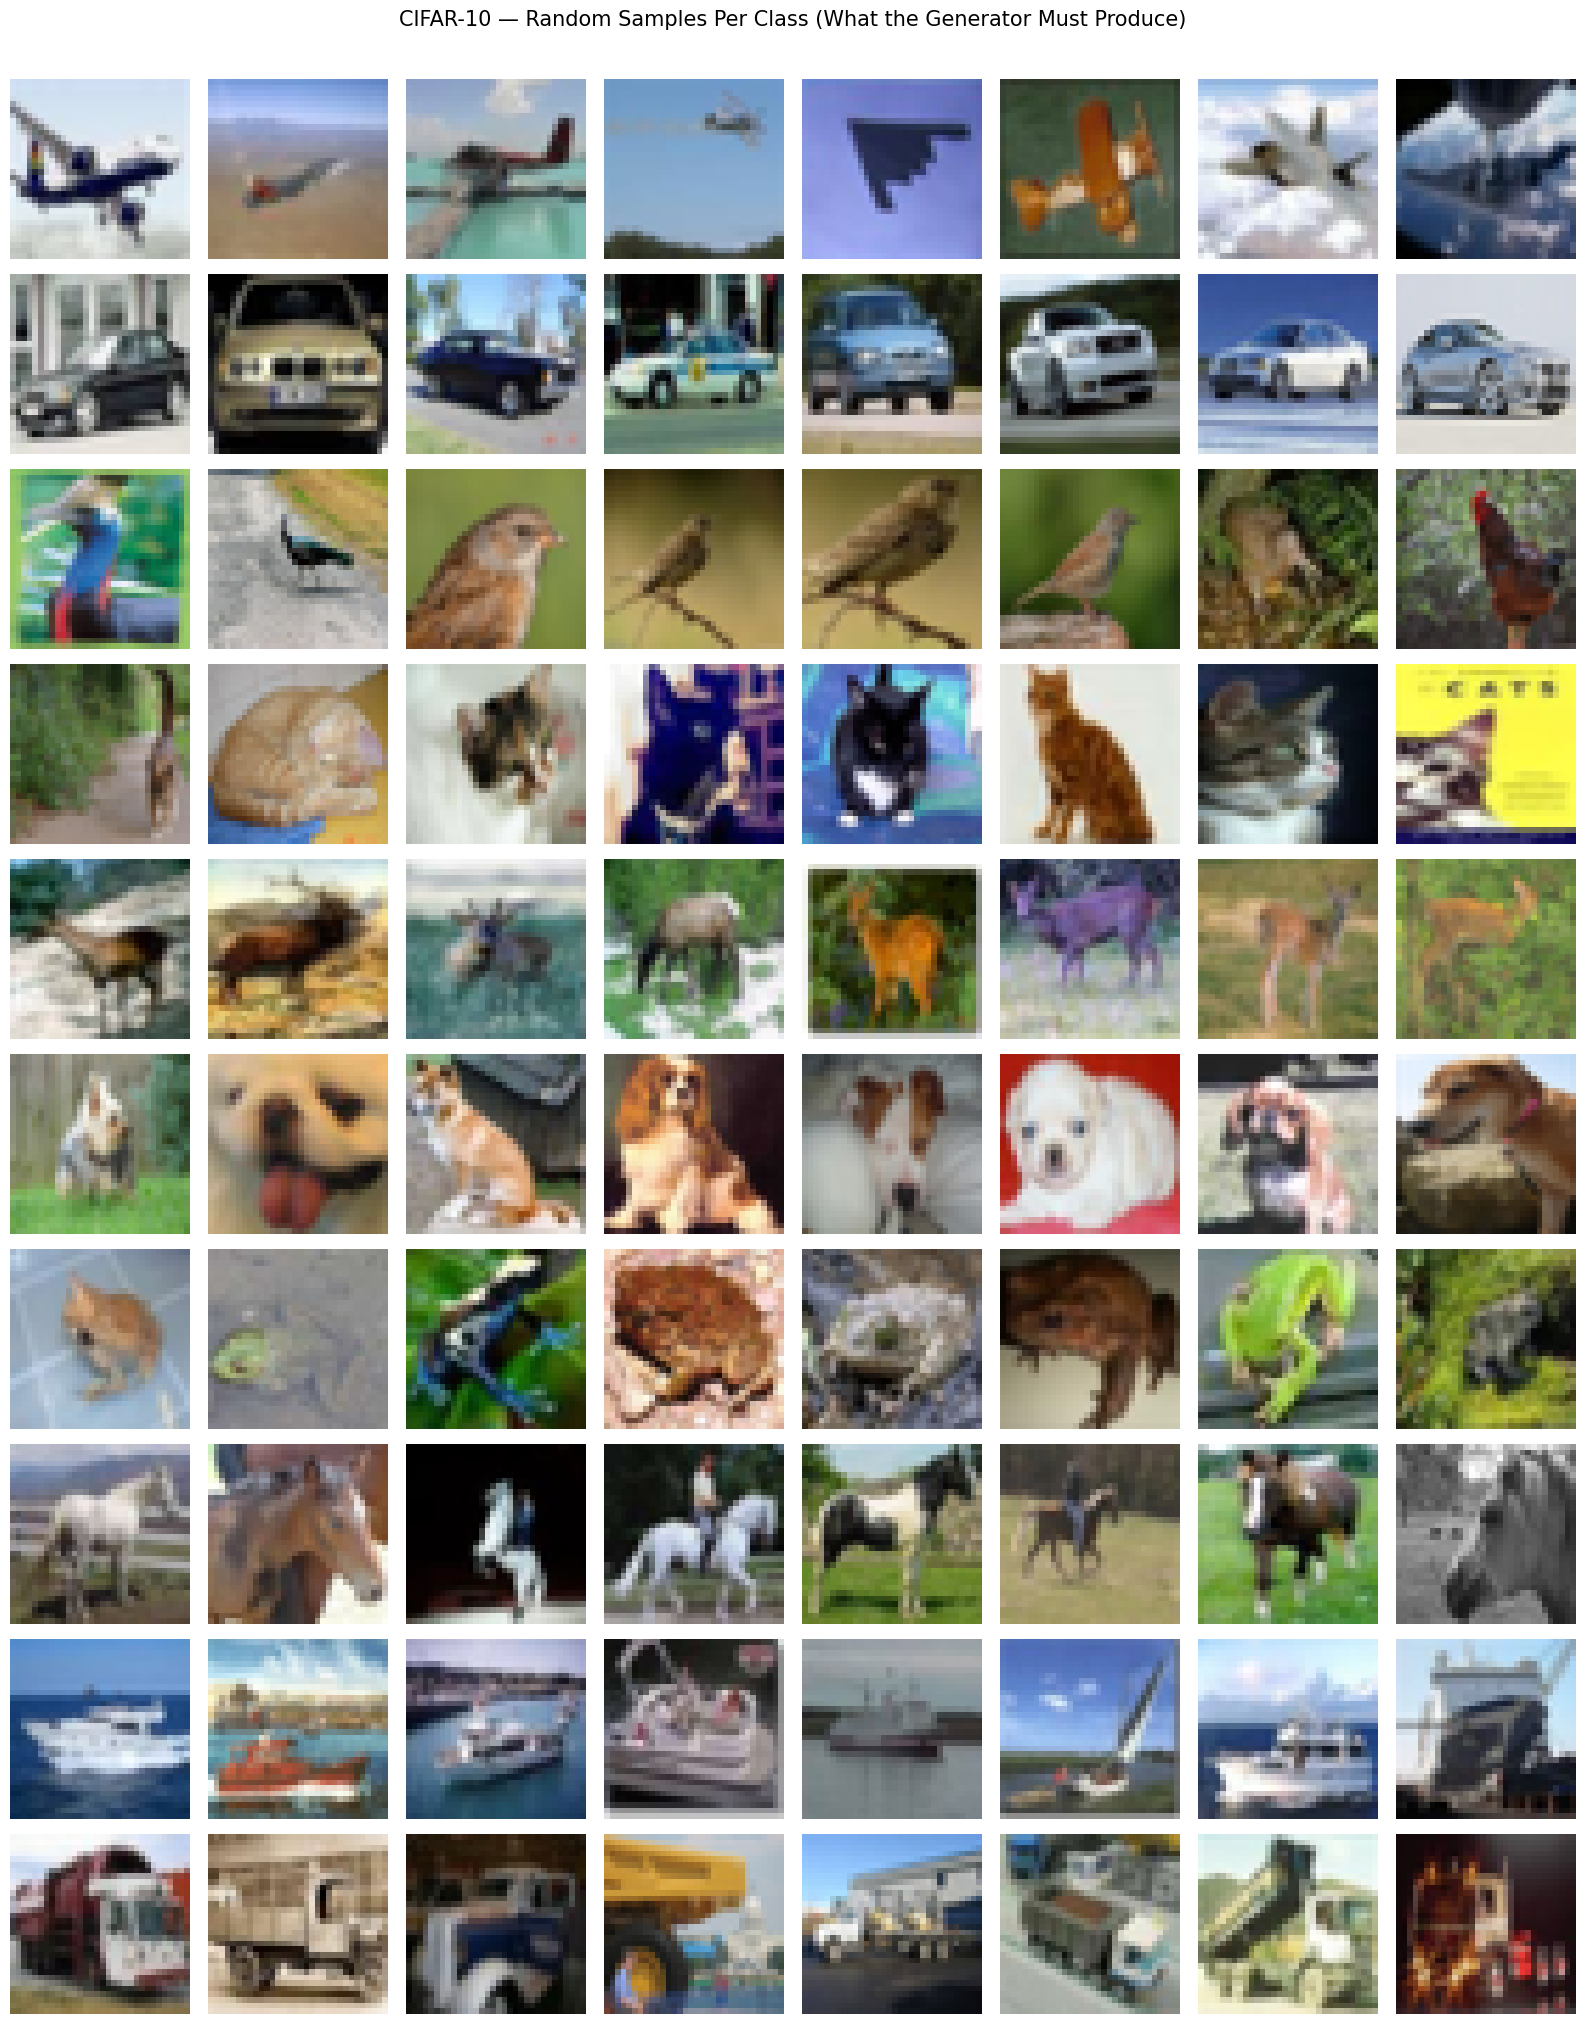


Key observations:
  - 32x32 resolution is low — fine details lost, shapes dominate
  - Some classes share visual features (automobile/truck, cat/dog, deer/horse)
  - Background variation is high within classes (diverse scenes)
  - Generator must learn both object shape AND background diversity


In [3]:
# Step 3: [2/5] Per-Class Visual Survey

"""
Display random samples from each class — this is what the generator
must learn to produce. At 32x32, some classes are ambiguous even to
humans (cat vs dog, automobile vs truck). Understanding the target
distribution helps interpret generator quality later.
"""

print("=" * 60)
print("[2/5] PER-CLASS VISUAL SURVEY")
print("=" * 60)

N_SAMPLES = 8  # columns per class

fig, axes = plt.subplots(10, N_SAMPLES, figsize=(16, 20))

for row, class_idx in enumerate(range(10)):
    # Get all images for this class
    class_mask = y_train == class_idx
    class_images = X_train_raw[class_mask]

    # Random sample
    rng = np.random.RandomState(RANDOM_STATE + class_idx)
    sample_idx = rng.choice(len(class_images), N_SAMPLES, replace=False)

    for col in range(N_SAMPLES):
        axes[row, col].imshow(class_images[sample_idx[col]])
        axes[row, col].axis('off')

    # Class label on leftmost image
    axes[row, 0].set_ylabel(CLASS_NAMES[class_idx], fontsize=12,
                             rotation=0, labelpad=70, va='center')

fig.suptitle('CIFAR-10 — Random Samples Per Class (What the Generator Must Produce)',
             fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, 'per_class_samples.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\nKey observations:")
print("  - 32x32 resolution is low — fine details lost, shapes dominate")
print("  - Some classes share visual features (automobile/truck, cat/dog, deer/horse)")
print("  - Background variation is high within classes (diverse scenes)")
print("  - Generator must learn both object shape AND background diversity")

[3/5] PIXEL STATISTICS

Per-channel statistics (uint8 scale [0, 255]):
Channel        Mean      Std    Min    Max   Median
--------------------------------------------------
Red          125.31    62.99      0    255    123.0
Green        122.95    62.09      0    255    121.0
Blue         113.87    66.70      0    255    104.0

Overall      120.71    64.15      0    255    117.0


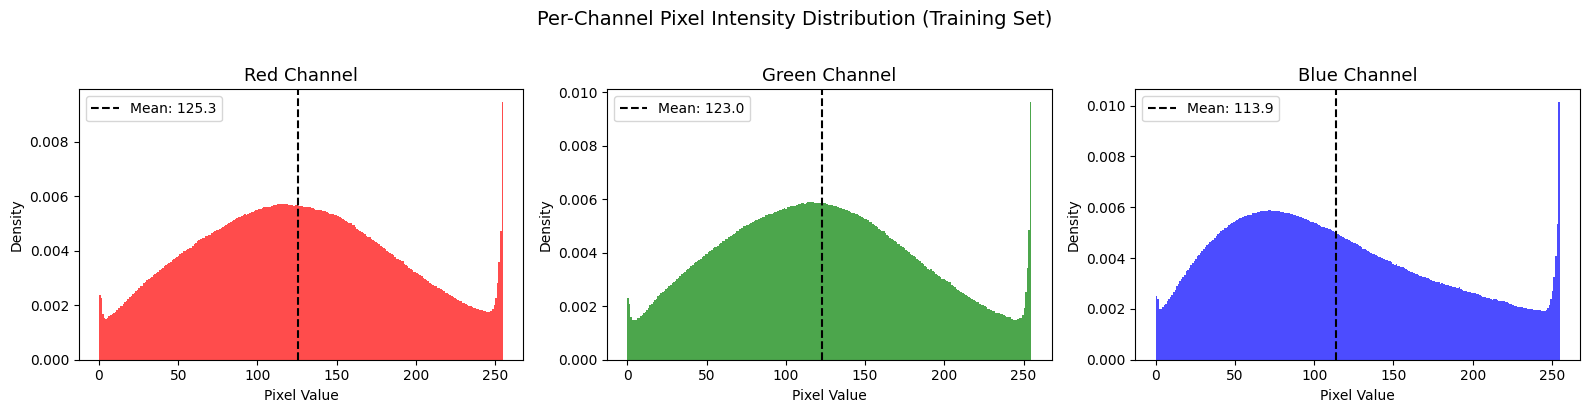


After GAN normalization (pixel / 127.5 - 1.0):
  Red: mean=-0.0172, std=0.4941, range=[-1.000, 1.000]
  Green: mean=-0.0357, std=0.4870, range=[-1.000, 1.000]
  Blue: mean=-0.1069, std=0.5232, range=[-1.000, 1.000]
  Overall: mean=-0.0533, std=0.5031

Key takeaway: Channels are NOT centered at 0 after [-1, 1] normalization.
  Generator tanh output range [-1, 1] covers full pixel range.
  Slight green/blue bias — generated images should show similar bias if trained well.


In [4]:
# Step 4: [3/5] Pixel Statistics

"""
Per-channel (R, G, B) mean and standard deviation across the training set.
A well-trained generator must match these first-order statistics — if
generated images have wrong color distributions, something is broken.
These stats also inform the normalization choice: [-1, 1] for tanh output.
"""

print("=" * 60)
print("[3/5] PIXEL STATISTICS")
print("=" * 60)

# Convert to float for stats
X_float = X_train_raw.astype(np.float32)

# Per-channel stats (across all pixels in all images)
channel_names = ['Red', 'Green', 'Blue']
print("\nPer-channel statistics (uint8 scale [0, 255]):")
print(f"{'Channel':<10} {'Mean':>8} {'Std':>8} {'Min':>6} {'Max':>6} {'Median':>8}")
print("-" * 50)
for c, name in enumerate(channel_names):
    ch = X_float[:, :, :, c]
    print(f"{name:<10} {ch.mean():>8.2f} {ch.std():>8.2f} {ch.min():>6.0f} {ch.max():>6.0f} {np.median(ch):>8.1f}")

# Overall stats
print(f"\n{'Overall':<10} {X_float.mean():>8.2f} {X_float.std():>8.2f} {X_float.min():>6.0f} {X_float.max():>6.0f} {np.median(X_float):>8.1f}")

# Per-channel histograms
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
colors = ['red', 'green', 'blue']

for c, (name, color) in enumerate(zip(channel_names, colors)):
    ch_data = X_float[:, :, :, c].flatten()
    axes[c].hist(ch_data, bins=256, range=(0, 255), color=color, alpha=0.7, density=True)
    axes[c].axvline(ch_data.mean(), color='black', linestyle='--', linewidth=1.5,
                    label=f'Mean: {ch_data.mean():.1f}')
    axes[c].set_title(f'{name} Channel', fontsize=13)
    axes[c].set_xlabel('Pixel Value')
    axes[c].set_ylabel('Density')
    axes[c].legend()

plt.suptitle('Per-Channel Pixel Intensity Distribution (Training Set)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, 'pixel_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()

# After [-1, 1] normalization
print("\nAfter GAN normalization (pixel / 127.5 - 1.0):")
X_norm = X_float / 127.5 - 1.0
for c, name in enumerate(channel_names):
    ch = X_norm[:, :, :, c]
    print(f"  {name}: mean={ch.mean():+.4f}, std={ch.std():.4f}, range=[{ch.min():.3f}, {ch.max():.3f}]")
print(f"  Overall: mean={X_norm.mean():+.4f}, std={X_norm.std():.4f}")

print("\nKey takeaway: Channels are NOT centered at 0 after [-1, 1] normalization.")
print("  Generator tanh output range [-1, 1] covers full pixel range.")
print("  Slight green/blue bias — generated images should show similar bias if trained well.")

[4/5] INTRA-CLASS DIVERSITY ANALYSIS

Per-class pixel variance (higher = more diverse):
Class             Mean Var    Std Var
----------------------------------------
airplane            3950.4       62.8
automobile          4479.8       66.7
bird                3428.4       58.4
cat                 4233.5       64.9
deer                2891.7       53.6
dog                 3929.9       62.6
frog                3198.2       56.2
horse               3840.5       61.6
ship                3498.3       59.1
truck               4089.6       63.7

Most diverse:  automobile (4479.8)
Least diverse: deer (2891.7)

Computing PCA projection (2 components on flattened pixels)...
  Explained variance: 40.3% (2 PCs)


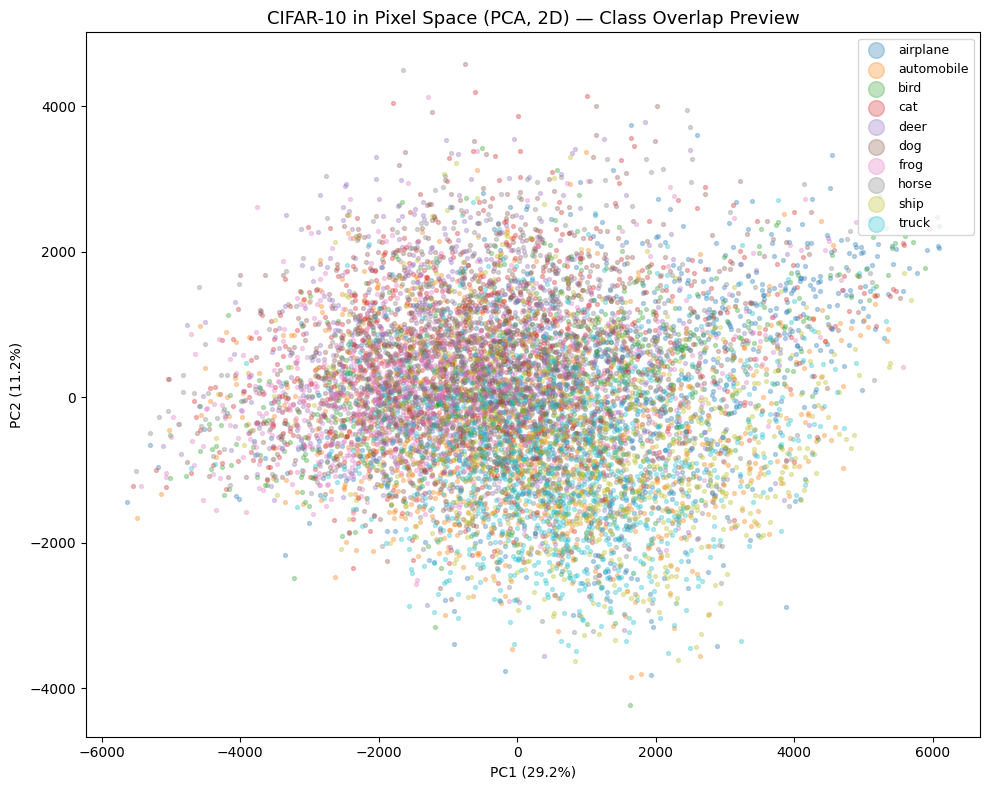


Key takeaway: Heavy overlap in pixel space — classes are NOT linearly separable.
  Mode collapse would show as tight clusters instead of this broad spread.
  A good generator must reproduce the FULL spread, not just cluster centers.


In [5]:
# Step 5: [4/5] Intra-class Diversity Analysis

"""
Show how much variation exists WITHIN each class. This is critical for
understanding mode collapse — if a GAN collapses, it produces only
the 'average' image for each class instead of the full spread.
PCA projection shows how much overlap exists between classes in pixel space.
"""

print("=" * 60)
print("[4/5] INTRA-CLASS DIVERSITY ANALYSIS")
print("=" * 60)

# Per-class pixel variance (measures visual diversity within each class)
print("\nPer-class pixel variance (higher = more diverse):")
print(f"{'Class':<15} {'Mean Var':>10} {'Std Var':>10}")
print("-" * 40)

class_variances = []
for i, name in enumerate(CLASS_NAMES):
    class_images = X_float[y_train == i]
    # Variance of each pixel position across all images in the class
    pixel_var = class_images.var(axis=0).mean()
    pixel_std = class_images.std(axis=0).mean()
    class_variances.append(pixel_var)
    print(f"{name:<15} {pixel_var:>10.1f} {pixel_std:>10.1f}")

# Rank by diversity
sorted_idx = np.argsort(class_variances)[::-1]
print(f"\nMost diverse:  {CLASS_NAMES[sorted_idx[0]]} ({class_variances[sorted_idx[0]]:.1f})")
print(f"Least diverse: {CLASS_NAMES[sorted_idx[-1]]} ({class_variances[sorted_idx[-1]]:.1f})")

# PCA projection — 2D view of class overlap
from sklearn.decomposition import PCA

print("\nComputing PCA projection (2 components on flattened pixels)...")
X_flat = X_float.reshape(len(X_float), -1)

# Subsample for speed (10K samples)
rng = np.random.RandomState(RANDOM_STATE)
sub_idx = rng.choice(len(X_flat), 10000, replace=False)
X_sub = X_flat[sub_idx]
y_sub = y_train[sub_idx]

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_sub)
print(f"  Explained variance: {pca.explained_variance_ratio_.sum():.1%} (2 PCs)")

# Scatter plot
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
cmap = plt.cm.tab10

for i, name in enumerate(CLASS_NAMES):
    mask = y_sub == i
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=[cmap(i)],
               label=name, alpha=0.3, s=8)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title('CIFAR-10 in Pixel Space (PCA, 2D) — Class Overlap Preview', fontsize=13)
ax.legend(markerscale=4, fontsize=9, loc='upper right')

plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, 'pca_class_overlap.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\nKey takeaway: Heavy overlap in pixel space — classes are NOT linearly separable.")
print("  Mode collapse would show as tight clusters instead of this broad spread.")
print("  A good generator must reproduce the FULL spread, not just cluster centers.")

In [6]:
# Step 6: [5/5] Summary

"""
Consolidate findings into preprocessing decisions and architecture implications.
"""

print("=" * 60)
print("[5/5] EDA SUMMARY — KEY FINDINGS")
print("=" * 60)

print("""
Dataset: CIFAR-10
  - 50,000 train / 10,000 test images (32x32x3 RGB)
  - 10 classes, perfectly balanced (5,000 per class)
  - uint8 pixels [0, 255]

Pixel Statistics:
  - Per-channel means: R=125.3, G=123.0, B=113.9 (red-biased)
  - Per-channel std:   R=63.0,  G=62.1,  B=66.7  (blue most variable)
  - After [-1,1] norm: overall mean=-0.053, std=0.503

Diversity:
  - High intra-class variance (2,892 to 4,480 per-pixel variance)
  - Most diverse: automobile (varied colors, angles, backgrounds)
  - Least diverse: deer (consistent green/brown backgrounds)
  - Heavy class overlap in pixel space (40.3% explained in 2 PCs)
  - Mode collapse would produce only the cluster center — must check diversity

Preprocessing Decisions:
  1. Normalize to [-1, 1] via (pixel / 127.5) - 1.0 (tanh generator output)
  2. Keep image shape (32, 32, 3) — no flattening (GANs are convolutional)
  3. Preserve labels for conditional GAN (cGAN) — balanced, no weighting needed
  4. Test set reserved for FID computation only — never used in training

Architecture Implications:
  - 32x32 is small enough for standard DCGAN (4 conv layers each)
  - High diversity demands large enough latent dim (100 is standard)
  - Class overlap means unconditional GAN will mix classes — expected behavior
  - Conditional GAN should separate classes using label embedding
""")

[5/5] EDA SUMMARY — KEY FINDINGS

Dataset: CIFAR-10
  - 50,000 train / 10,000 test images (32x32x3 RGB)
  - 10 classes, perfectly balanced (5,000 per class)
  - uint8 pixels [0, 255]

Pixel Statistics:
  - Per-channel means: R=125.3, G=123.0, B=113.9 (red-biased)
  - Per-channel std:   R=63.0,  G=62.1,  B=66.7  (blue most variable)
  - After [-1,1] norm: overall mean=-0.053, std=0.503

Diversity:
  - High intra-class variance (2,892 to 4,480 per-pixel variance)
  - Most diverse: automobile (varied colors, angles, backgrounds)
  - Least diverse: deer (consistent green/brown backgrounds)
  - Heavy class overlap in pixel space (40.3% explained in 2 PCs)
  - Mode collapse would produce only the cluster center — must check diversity

Preprocessing Decisions:
  1. Normalize to [-1, 1] via (pixel / 127.5) - 1.0 (tanh generator output)
  2. Keep image shape (32, 32, 3) — no flattening (GANs are convolutional)
  3. Preserve labels for conditional GAN (cGAN) — balanced, no weighting needed
  4. 